# 03. Caption 文本细粒度分析（懂物料任务的输入侧画像）

> 对应 `analysis_plan.md` §2.3。**§2.2 已经完成 caption 类型判别 / 字符长度分位 / orphan 清单**，本 notebook 只做 §2.2 未覆盖的部分，避免重复 IO。

## 目的

1. **真实 token 数分布**（用 `OneReason-0.8B-Pretrain` 的 tokenizer 而不是字符数） —— 直接决定 SFT 时 `max_source_length`。
2. **重复率**（同一 caption 对应多少 pid） —— 决定去重策略。
3. **语言分布**（中/英/其他） —— 决定 prompt 模板要不要多语言。
4. **关键词 TF-IDF**（jieba 分词，每域 top-K） —— 快速看行业分布，用于兴趣演化任务的题目采样。
5. **live 域 taglist 展开分析** —— live 域 caption 是关键词列表，展开后的关键词个数、词表大小、频次分布；直接指导建议 I 里"关键词 → SID"任务的 prompt 构造。

## 输入 / 输出

**输入**：`dataset_rec_all/data/OneReason_Pid2Caption/*.parquet`

**输出**（`analysis/outputs/caption/`）：
- `token_length_stats.csv` —— 每 domain 的 token 数 P50/P90/P99/max（真实 tokenizer）
- `duplication_stats.csv` —— 每 domain 的 caption 重复率
- `language_stats.csv` —— 中/英/其他分布
- `keywords_top100_{domain}.csv` —— 每 domain top-100 关键词（TF-IDF）
- `live_taglist_stats.csv` —— live 展开后的 tag 数、词表、top-100 tag
- 相应的 png

In [11]:
# ============ 配置 & imports ============
import os, ast, hashlib, pickle, time, re, unicodedata
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

# ---- macOS 中文显示修复：不然中文标签会显示成 tofu 方块 ----
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Songti SC', 'STHeiti', 'Hiragino Sans GB', 'PingFang SC', 'Heiti SC', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

PROJECT_ROOT = Path('/Users/cjs/Desktop/MY/explore_llm_rec')
PID2CAP_DIR  = PROJECT_ROOT / 'dataset_rec_all' / 'data' / 'OneReason_Pid2Caption'
TOKENIZER_DIR = PROJECT_ROOT / 'OneReason-0.8B-Pretrain'
OUT_DIR      = PROJECT_ROOT / 'analysis' / 'outputs' / 'caption'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- 参数 ----
SAMPLE_FRAC = 0.1   # caption 表 6GB，10% 抽样已足够画分布
TOKEN_SAMPLE_N = 20000  # 每 domain 抽 20000 条做真实 tokenize
USE_CACHE   = True
CACHE_PATH  = OUT_DIR / '_cache.pkl'

print('Pid2Caption dir :', PID2CAP_DIR)
print('Tokenizer dir   :', TOKENIZER_DIR)
print('Output dir      :', OUT_DIR)

# ---- Tokenizer 加载（懒加载，失败不影响其他分析） ----
TOKENIZER = None
try:
    from transformers import AutoTokenizer
    TOKENIZER = AutoTokenizer.from_pretrained(str(TOKENIZER_DIR), trust_remote_code=True)
    print(f'[tokenizer] loaded, vocab_size={TOKENIZER.vocab_size}')
except Exception as e:
    print(f'[tokenizer] load failed: {e}\n  → 会退化用 len(text)/2 估算 token 数')

Pid2Caption dir : /Users/cjs/Desktop/MY/explore_llm_rec/dataset_rec_all/data/OneReason_Pid2Caption
Tokenizer dir   : /Users/cjs/Desktop/MY/explore_llm_rec/OneReason-0.8B-Pretrain
Output dir      : /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/caption
[tokenizer] loaded, vocab_size=151643


## 单遍抽样扫描：一次收集 5 类统计

为避免 6GB caption 表重复读，一遍扫描内同时收集：
- 每 domain 一个 caption 抽样池（用于 tokenize、TF-IDF、taglist 展开）
- 每 domain 的 caption hash Counter（用于重复率）
- 每 domain 的字符集分类计数（中/英/数字/其他）

In [12]:
# ---- 字符类分类器 ----
_CN_RE  = re.compile(r'[\u4e00-\u9fff]')
_EN_RE  = re.compile(r'[A-Za-z]')
_JP_RE  = re.compile(r'[\u3040-\u30ff]')
_KO_RE  = re.compile(r'[\uac00-\ud7af]')

def dominant_lang(text: str) -> str:
    if not text: return 'empty'
    n_cn = len(_CN_RE.findall(text))
    n_en = len(_EN_RE.findall(text))
    n_jp = len(_JP_RE.findall(text))
    n_ko = len(_KO_RE.findall(text))
    total = max(1, len(text))
    if n_cn / total > 0.3: return 'zh'
    if n_jp / total > 0.15: return 'ja'
    if n_ko / total > 0.15: return 'ko'
    if n_en / total > 0.3: return 'en'
    return 'other'


def scan_captions(directory: Path, sample_frac: float, per_domain_pool_size: int):
    dup_hash    = defaultdict(Counter)   # domain -> Counter(hash -> n_pid)
    lang_cnt    = defaultdict(Counter)   # domain -> Counter(lang -> n)
    caption_pool = defaultdict(list)     # domain -> 抽样文本池（后续 tokenize/TFIDF 用）
    total_seen   = Counter()
    files = sorted(directory.glob('part-*.parquet'))
    t0 = time.time()
    for i, fp in enumerate(files):
        if fp.stat().st_size == 0:  # 有可能有 0 字节 empty file
            continue
        pf = pq.ParquetFile(fp)
        for rg in range(pf.num_row_groups):
            tbl = pf.read_row_group(rg, columns=['domain', 'caption'])
            df = tbl.to_pandas()
            if sample_frac < 1.0:
                df = df.sample(frac=sample_frac, random_state=2026)
            for domain, sub in df.groupby('domain', sort=False):
                caps = sub['caption'].fillna('').tolist()
                for c in caps:
                    total_seen[domain] += 1
                    h = hashlib.md5(c.encode('utf-8')).digest()[:8]
                    dup_hash[domain][h] += 1
                    lang_cnt[domain][dominant_lang(c)] += 1
                    if len(caption_pool[domain]) < per_domain_pool_size:
                        caption_pool[domain].append(c)
        if (i + 1) % 20 == 0 or i == len(files) - 1:
            print(f'  scanned {i+1}/{len(files)} caption parquet, elapsed {time.time()-t0:.1f}s')
    return {
        'dup_hash':     {d: dict(c) for d, c in dup_hash.items()},
        'lang_cnt':     {d: dict(c) for d, c in lang_cnt.items()},
        'caption_pool': dict(caption_pool),
        'total_seen':   dict(total_seen),
    }


if USE_CACHE and CACHE_PATH.exists():
    print(f'[cache] loading {CACHE_PATH} ...')
    with open(CACHE_PATH, 'rb') as f:
        stats = pickle.load(f)
    print('[cache] loaded.')
else:
    stats = scan_captions(PID2CAP_DIR, SAMPLE_FRAC, TOKEN_SAMPLE_N)
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(stats, f)
    print(f'[cache] saved to {CACHE_PATH}')

print('\n=== per-domain sampled sizes ===')
for d, n in sorted(stats['total_seen'].items()):
    print(f'  {d:<12s} sampled={n:>8,}  pool={len(stats["caption_pool"].get(d, [])):>6,}')

  scanned 20/136 caption parquet, elapsed 3.9s
  scanned 40/136 caption parquet, elapsed 7.7s
  scanned 60/136 caption parquet, elapsed 11.2s
  scanned 80/136 caption parquet, elapsed 14.9s
  scanned 100/136 caption parquet, elapsed 18.5s
  scanned 120/136 caption parquet, elapsed 22.1s
  scanned 136/136 caption parquet, elapsed 24.7s
[cache] saved to /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/caption/_cache.pkl

=== per-domain sampled sizes ===
  goods        sampled= 977,665  pool=20,000
  live         sampled=  10,343  pool=10,343
  video/ad     sampled= 141,435  pool=20,000
  video/video  sampled= 976,687  pool=20,000


## §2.3.1 真实 Token 数分布（决定 max_source_length）

字符数 ≠ token 数。中文一般 1 char ≈ 1~1.5 token，英文一般 1 word ≈ 1.3 token。
用真实 tokenizer 才能给出可靠的 `max_source_length` 建议。

In [13]:
def batch_token_len(texts, batch_size=256):
    if TOKENIZER is None:
        return np.array([max(1, int(len(t) * 0.6)) for t in texts])
    lens = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = TOKENIZER(batch, add_special_tokens=False, return_length=True, truncation=False)
        lens.extend(enc['length'])
    return np.array(lens)


token_rows = []
for domain in sorted(stats['caption_pool']):
    pool = stats['caption_pool'][domain]
    if not pool:
        continue
    print(f'  tokenizing {domain} × {len(pool)} ...')
    t0 = time.time()
    lens = batch_token_len(pool)
    print(f'    done in {time.time()-t0:.1f}s')
    token_rows.append({
        'domain':    domain,
        'sample_n':  len(pool),
        'p50':       int(np.percentile(lens, 50)),
        'p90':       int(np.percentile(lens, 90)),
        'p95':       int(np.percentile(lens, 95)),
        'p99':       int(np.percentile(lens, 99)),
        'max':       int(lens.max()),
        'mean':      round(float(lens.mean()), 1),
        'std':       round(float(lens.std()), 1),
    })

tok_df = pd.DataFrame(token_rows)
tok_df.to_csv(OUT_DIR / 'token_length_stats.csv', index=False)
print('saved:', OUT_DIR / 'token_length_stats.csv')
tok_df

  tokenizing goods × 20000 ...
    done in 0.1s
  tokenizing live × 10343 ...
    done in 0.3s
  tokenizing video/ad × 20000 ...
    done in 0.8s
  tokenizing video/video × 20000 ...
    done in 0.7s
saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/caption/token_length_stats.csv


,domain,sample_n,p50,p90,p95,p99,max,mean,std
0,goods,20000,22,28,29,32,46,20.5,6.5
1,live,10343,43,55,59,69,118,43.9,8.9
2,video/ad,20000,178,214,226,253,1160,179.3,29.0
3,video/video,20000,172,212,225,251,392,166.2,40.8


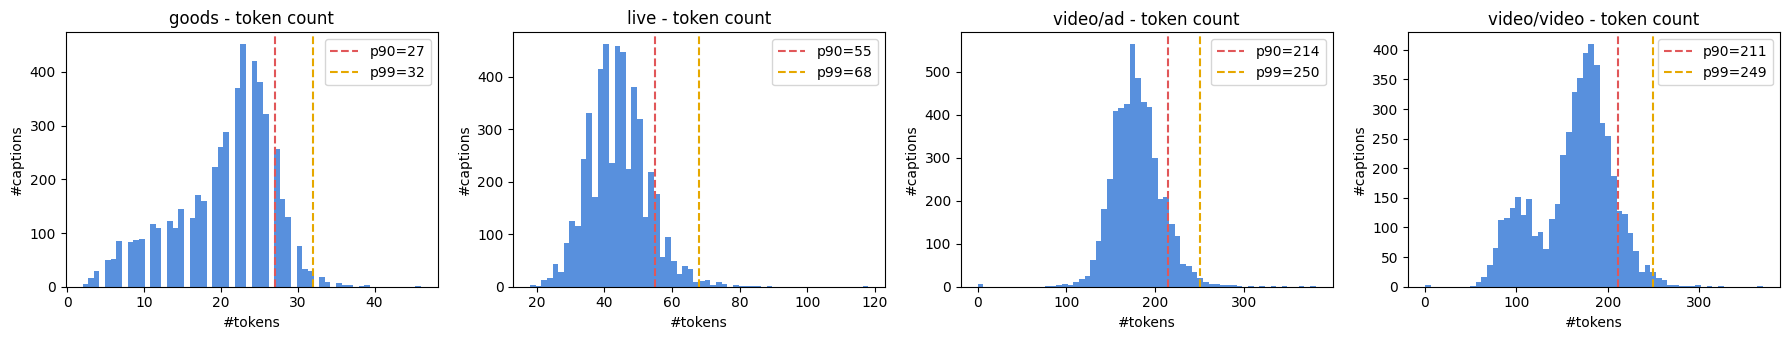

In [14]:
# 画 token 数直方图（每 domain 一个）
fig, axes = plt.subplots(1, len(stats['caption_pool']), figsize=(4.5 * len(stats['caption_pool']), 3.5), squeeze=False)
for i, domain in enumerate(sorted(stats['caption_pool'])):
    pool = stats['caption_pool'][domain]
    if not pool:
        continue
    lens = batch_token_len(pool[:5000])
    ax = axes[0][i]
    ax.hist(lens, bins=60, color='#3b7dd8', alpha=0.85)
    ax.axvline(np.percentile(lens, 90), color='#e15759', ls='--', label=f'p90={int(np.percentile(lens, 90))}')
    ax.axvline(np.percentile(lens, 99), color='#e6a800', ls='--', label=f'p99={int(np.percentile(lens, 99))}')
    ax.set_title(f'{domain} - token count')
    ax.set_xlabel('#tokens'); ax.set_ylabel('#captions'); ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'token_length_hist.png', dpi=110)
plt.show()

## §2.3.2 重复率：同 caption 多个 pid

In [15]:
dup_rows = []
for domain, hash_ctr in sorted(stats['dup_hash'].items()):
    total = sum(hash_ctr.values())
    unique = len(hash_ctr)
    dupd = sum(1 for v in hash_ctr.values() if v > 1)     # 被多个 pid 共享的 caption 个数
    dup_rows_hit = sum(v for v in hash_ctr.values() if v > 1)  # 落在重复 caption 上的样本数
    max_share = max(hash_ctr.values()) if hash_ctr else 0
    dup_rows.append({
        'domain':                   domain,
        'sampled_rows':             total,
        'unique_captions':          unique,
        'unique_%':                 round(unique / max(1, total) * 100, 2),
        'shared_captions':          dupd,
        'shared_captions_%':        round(dupd / max(1, unique) * 100, 2),
        'rows_on_shared_captions_%': round(dup_rows_hit / max(1, total) * 100, 2),
        'max_pids_per_caption':     max_share,
    })

dup_df = pd.DataFrame(dup_rows)
dup_df.to_csv(OUT_DIR / 'duplication_stats.csv', index=False)
print('saved:', OUT_DIR / 'duplication_stats.csv')
dup_df

saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/caption/duplication_stats.csv


,domain,sampled_rows,unique_captions,unique_%,shared_captions,shared_captions_%,rows_on_shared_captions_%,max_pids_per_caption
0,goods,977665,922483,94.36,30672,3.32,8.78,179
1,live,10343,10343,100.00,0,0.00,0.00,1
2,video/ad,141435,137941,97.53,1820,1.32,3.76,275
3,video/video,976687,974374,99.76,691,0.07,0.31,1145


## §2.3.3 语言分布

In [16]:
lang_rows = []
for domain, lc in sorted(stats['lang_cnt'].items()):
    total = sum(lc.values())
    row = {'domain': domain, 'total': total}
    for lang in ['zh', 'en', 'ja', 'ko', 'other', 'empty']:
        row[lang] = round(lc.get(lang, 0) / max(1, total) * 100, 2)
    lang_rows.append(row)
lang_df = pd.DataFrame(lang_rows)
lang_df.to_csv(OUT_DIR / 'language_stats.csv', index=False)
print('saved:', OUT_DIR / 'language_stats.csv')
lang_df

saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/caption/language_stats.csv


,domain,total,zh,en,ja,ko,other,empty
0,goods,977665,99.29,0.30,0.0,0.0,0.41,0.00
1,live,10343,99.98,0.02,0.0,0.0,0.00,0.00
2,video/ad,141435,99.80,0.00,0.0,0.0,0.00,0.19
3,video/video,976687,99.88,0.00,0.0,0.0,0.01,0.12


## §2.3.4 关键词 TF-IDF（快速看行业分布）

- 用 jieba 分词，去停用词。
- 每 domain 用 `TfidfVectorizer` 找 top-100 关键词。
- 结果给出该 domain 的"行业主题池"，可用于兴趣演化任务的题目采样。

In [17]:
try:
    import jieba
    HAS_JIEBA = True
except ImportError:
    HAS_JIEBA = False
    print('[warn] jieba 未安装，请运行 pip install jieba')

try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    HAS_SK = True
except ImportError:
    HAS_SK = False
    print('[warn] sklearn 未安装')

# 简易停用词
STOPWORDS = set('的 了 是 在 和 有 也 就 都 与 或 而 及 一个 一些 这 那 这个 那个 这些 那些 视频 展示 关于 一位 出现 通过 该 提供 强调 兴趣点 观众 画面 场景 内容 这是'.split())
STOPWORDS |= set('。 ， 、 ； ： ！ ？ … 《 》 「 」 【 】 ( ) [ ] { } - + = / \\ | ~ * # @ $ % & ^'.split())
STOPWORDS |= set('the a an of to in for on at by is are was were be been being has have had do does did'.split())


def tokenize_zh(text):
    if not text: return []
    if HAS_JIEBA:
        return [w for w in jieba.lcut(text) if len(w) >= 2 and w not in STOPWORDS and not w.isdigit()]
    else:
        # 退化：按字符 2-gram
        return [text[i:i+2] for i in range(len(text)-1) if len(text[i:i+2].strip()) == 2]


def top_keywords_tfidf(texts, top_k=100):
    if not HAS_SK or not texts:
        # 退化到简单 TF
        c = Counter()
        for t in texts:
            c.update(tokenize_zh(t))
        return [(w, cnt) for w, cnt in c.most_common(top_k)]
    docs = [' '.join(tokenize_zh(t)) for t in texts]
    vec = TfidfVectorizer(max_features=20000, min_df=3)
    try:
        M = vec.fit_transform(docs)
    except ValueError:
        return []
    scores = np.asarray(M.sum(axis=0)).ravel()
    vocab  = vec.get_feature_names_out()
    order  = scores.argsort()[::-1][:top_k]
    return [(vocab[i], float(scores[i])) for i in order]


for domain, pool in sorted(stats['caption_pool'].items()):
    if domain == 'live':
        continue  # live 是 taglist，走单独分析
    if not pool:
        continue
    # 只对 describe 类型做 TF-IDF；先粗过滤
    texts = [t for t in pool if t and len(t) > 10 and not (t.startswith('[') and t.endswith(']'))]
    print(f'\n{domain}: {len(texts)} caption for TF-IDF')
    top = top_keywords_tfidf(texts[:5000], top_k=100)
    df_top = pd.DataFrame(top, columns=['keyword', 'tfidf_score'])
    safe = domain.replace('/', '_')
    df_top.to_csv(OUT_DIR / f'keywords_top100_{safe}.csv', index=False)
    print(f'  top-20: {[k for k,_ in top[:20]]}')
    print(f'  saved  keywords_top100_{safe}.csv')

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Building prefix dict from the default dictionary ...



goods: 18601 caption for TF-IDF


Dumping model to file cache /var/folders/ld/smy2vf8n11zbd4wf48hbyy_c0000gn/T/jieba.cache
Loading model cost 0.174 seconds.
Prefix dict has been built successfully.


  top-20: ['新款', '休闲', '时尚', '专属', '夏季', '家用', '百搭', '加厚', '男士', '外套', '套装', '男女', '上衣', '宽松', '手机', '儿童', '推荐', '短袖', '加绒', '专用']
  saved  keywords_top100_goods.csv

video/ad: 19963 caption for TF-IDF
  top-20: ['游戏', '活动', '应用', '吸引', '角色', '用户', '信息', '玩家', '女性', '文字', '促销', '可以', '情感', '产品', '一种', '兴趣', '在于', '喜欢', '此外', '整个']
  saved  keywords_top100_video_ad.csv

video/video: 19978 caption for TF-IDF
  top-20: ['游戏', '角色', '可能', '女性', '吸引', '情感', '玩家', '生活', '文字', '一种', '兴趣', '在于', '展现', '不同', '喜欢', '互动', '可以', '此外', '氛围', '整个']
  saved  keywords_top100_video_video.csv


## §2.3.5 Live 域 taglist 展开分析

live 域 caption = `['tag1', 'tag2', ...]`。展开后：
- 每条 caption 的 tag 数量分布（决定关键词→SID 任务的 prompt 长度）。
- 全域 tag 词表大小、出现频次分布 —— 与 `Pid2Tag.tag_lv3` 对比可见 live caption 的 tag 是**远比 lv3 更细粒度**的用户视角描述。
- Top-100 tag 输出。

live pool size = 10343
parse ok:            10343 / 10343
unique tags in pool: 37747
total tag mentions:  87197
#tags per caption   p50=8   p90=10   p99=13   max=18
tag freq p50=1   p90=3   top1=1160
saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/caption/live_taglist_stats.csv &  live_taglist_top100.csv


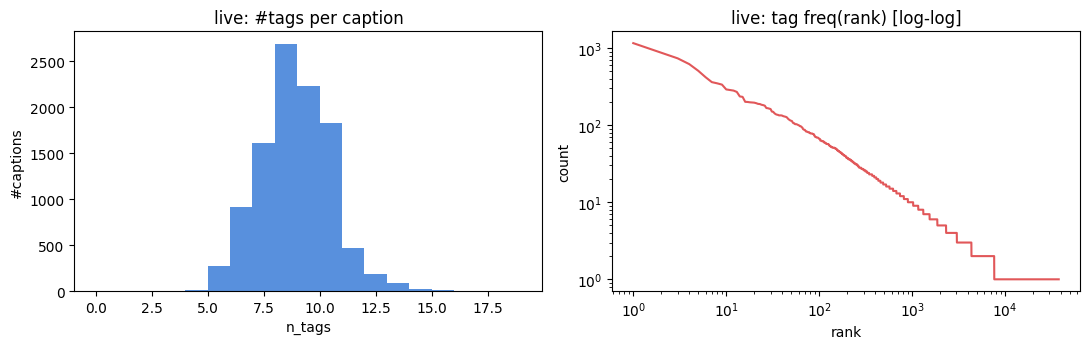


=== live top-30 tags ===
    1160 : 精致妆容
     871 : 长发造型
     737 : 露脸直播
     620 : 红唇妆容
     508 : 互动型主播
     419 : 露脸主播
     362 : 亲切互动
     349 : 好身材
     336 : 不露脸直播
     291 : 甜美长相
     286 : 长发美女
     281 : 唱歌才艺
     270 : 短发造型
     236 : 唱歌达人
     233 : 正能量传递
     201 : 情感互动
     200 : 互动型直播
     198 : 接地气
     197 : 生活化直播
     196 : PK互动
     193 : 唱歌互动
     189 : 温柔亲切
     188 : 休闲穿搭
     184 : 温柔气质
     182 : 亲切接地气
     179 : 音乐分享
     167 : 露脸互动
     166 : 生活分享
     164 : 情感分享
     162 : 互动聊天


In [18]:
live_pool = stats['caption_pool'].get('live', [])
print(f'live pool size = {len(live_pool)}')

tag_cnt = Counter()
num_tags_per_cap = []
parse_ok = 0
for cap in live_pool:
    if not cap:
        continue
    try:
        tags = ast.literal_eval(cap)
    except Exception:
        continue
    if not isinstance(tags, list):
        continue
    tags = [str(t).strip() for t in tags if str(t).strip()]
    if not tags:
        continue
    parse_ok += 1
    num_tags_per_cap.append(len(tags))
    tag_cnt.update(tags)

num_tags_arr = np.asarray(num_tags_per_cap) if num_tags_per_cap else np.array([0])

print(f'parse ok:            {parse_ok} / {len(live_pool)}')
print(f'unique tags in pool: {len(tag_cnt)}')
print(f'total tag mentions:  {sum(tag_cnt.values())}')
print(f'#tags per caption   p50={int(np.percentile(num_tags_arr, 50))}   '
      f'p90={int(np.percentile(num_tags_arr, 90))}   '
      f'p99={int(np.percentile(num_tags_arr, 99))}   '
      f'max={int(num_tags_arr.max())}')

# 频次分布
freqs = np.array(sorted(tag_cnt.values(), reverse=True))
print(f'tag freq p50={int(np.percentile(freqs, 50))}   '
      f'p90={int(np.percentile(freqs, 90))}   '
      f'top1={int(freqs[0]) if len(freqs) else 0}')

# 保存
top100 = tag_cnt.most_common(100)
pd.DataFrame(top100, columns=['tag', 'count']).to_csv(OUT_DIR / 'live_taglist_top100.csv', index=False)

summary = pd.DataFrame([{
    'sample_captions':          len(live_pool),
    'parse_ok':                 parse_ok,
    'unique_tags':              len(tag_cnt),
    'total_tag_mentions':       int(sum(tag_cnt.values())),
    'tags_per_caption_p50':     int(np.percentile(num_tags_arr, 50)) if parse_ok else 0,
    'tags_per_caption_p90':     int(np.percentile(num_tags_arr, 90)) if parse_ok else 0,
    'tags_per_caption_p99':     int(np.percentile(num_tags_arr, 99)) if parse_ok else 0,
    'tags_per_caption_max':     int(num_tags_arr.max()) if parse_ok else 0,
    'top1_tag':                 top100[0][0] if top100 else '',
    'top1_tag_count':           top100[0][1] if top100 else 0,
}])
summary.to_csv(OUT_DIR / 'live_taglist_stats.csv', index=False)
print('saved:', OUT_DIR / 'live_taglist_stats.csv',  '&  live_taglist_top100.csv')

# 图：#tags per caption + tag freq curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ax1.hist(num_tags_arr, bins=range(0, num_tags_arr.max() + 2), color='#3b7dd8', alpha=0.85)
ax1.set_title('live: #tags per caption'); ax1.set_xlabel('n_tags'); ax1.set_ylabel('#captions')
ax2.loglog(np.arange(1, len(freqs) + 1), freqs, color='#e15759')
ax2.set_title('live: tag freq(rank) [log-log]'); ax2.set_xlabel('rank'); ax2.set_ylabel('count')
plt.tight_layout()
plt.savefig(OUT_DIR / 'live_taglist_curves.png', dpi=110)
plt.show()

print('\n=== live top-30 tags ===')
for t, c in top100[:30]:
    print(f'  {c:>6} : {t}')

## §2.3.6 结论 & 对 SFT 的直接指导

把关键结论抄进 `analysis/report.md`：

1. **max_source_length 精修**：字符数 P90（§2.2）与 token 数 P90（§2.3.1）通常有 1.2~1.5x 的关系。用 `token_length_stats.csv` 的 P95/P99 来定 `max_source_length`（比 §2.2 建议的字符数更精确）。
2. **重复率**：如果某 domain 的 `unique_%` < 90%，说明有大量重复 caption；建议 SFT 时 **按 caption 去重后采样**（避免同一段文本被 20 个 pid 反复训练，梯度贡献不成比例）。
3. **语言分布**：如果 `en / ja / ko` 占比 > 5%，需要在 prompt 模板里加 language hint 或者做统一翻译预处理。
4. **关键词 top-100** 直接给到"兴趣演化任务"的题目采样池 —— 官方评测里出现过"石墨烯电热膜"这种细粒度题目，需要保证训练数据里有足够高频的相关关键词。
5. **live taglist 分析** 给出 §2.2 建议 I 的具体参数：
   - prompt 里应该保留多少 tag（用 `tags_per_caption_p50/p90` 决定）
   - 随机 mask 的最小保留数（避免留一个 tag 就直接猜 SID）

### 产出物清单（`analysis/outputs/caption/`）
- `token_length_stats.csv`, `token_length_hist.png`
- `duplication_stats.csv`
- `language_stats.csv`
- `keywords_top100_{goods,video_ad,video_video}.csv`
- `live_taglist_stats.csv`, `live_taglist_top100.csv`, `live_taglist_curves.png`
- `_cache.pkl`（供后续 notebook 复用）